In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('/home/mahaputra777/pt_skp/ContainerSmartStay/booking_Bedugul_1779757448025.xlsx')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3637 entries, 0 to 3636
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tanggal Stay   3637 non-null   object
 1   Check-in       3637 non-null   object
 2   Check-out      3637 non-null   object
 3   Nama Property  3637 non-null   object
 4   Harga          3637 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 142.2+ KB


In [5]:
df.head()

,Tanggal Stay,Check-in,Check-out,Nama Property,Harga
0,2026-05-27 to 2026-05-28,2026-05-27,2026-05-28,Strawberry Hill Hotel & Restaurant,765000
1,2026-05-27 to 2026-05-28,2026-05-27,2026-05-28,Pondok Nyoman Bedugul by AGATA,390520
2,2026-05-27 to 2026-05-28,2026-05-27,2026-05-28,Village Above The Clouds,569250
3,2026-05-27 to 2026-05-28,2026-05-27,2026-05-28,Warung Rekreasi Bedugul,719199
4,2026-05-27 to 2026-05-28,2026-05-27,2026-05-28,Navalia Villa Bedugul,729300


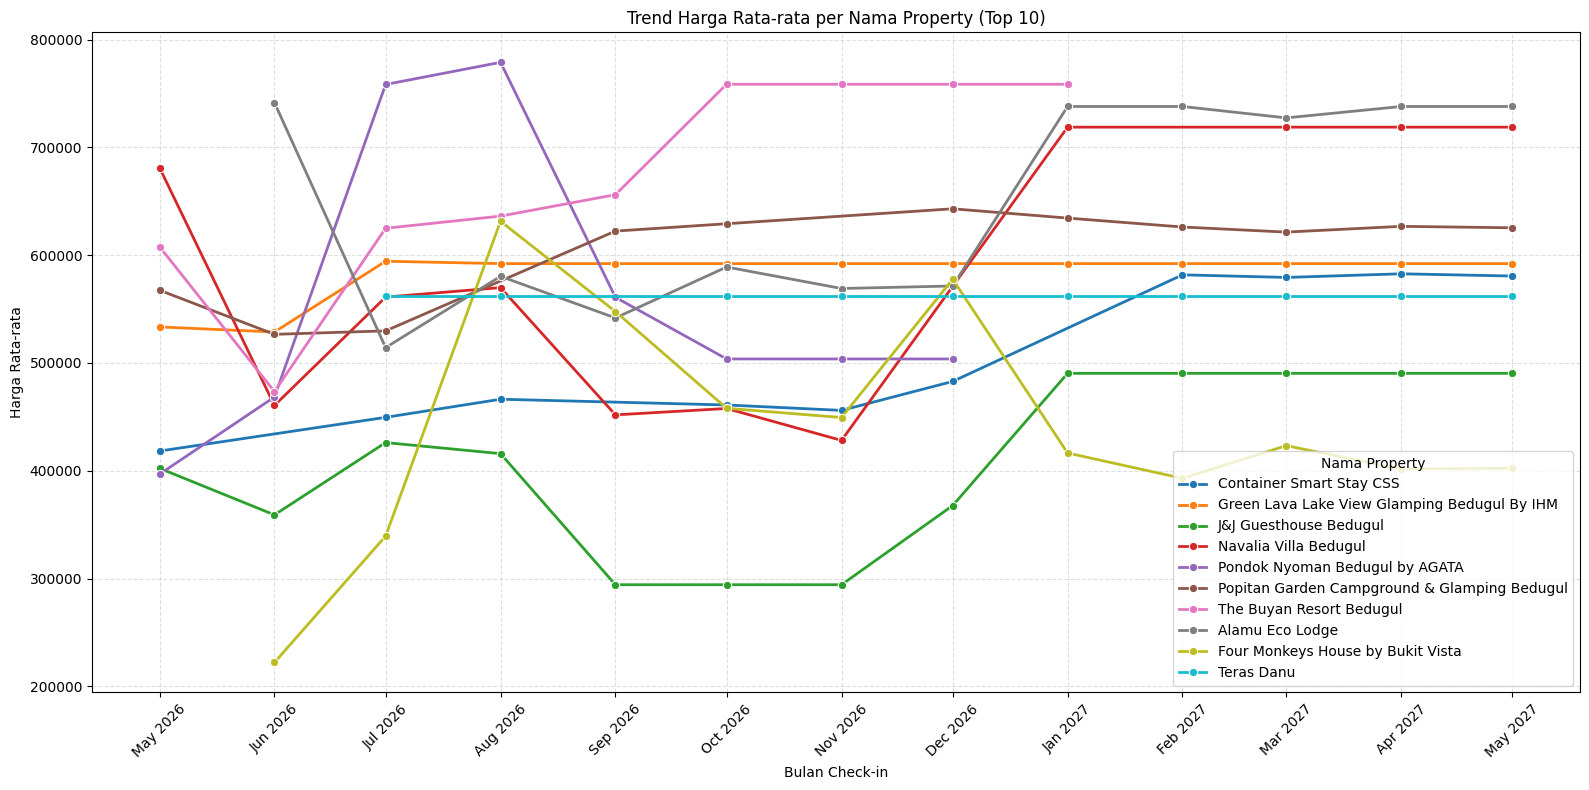

In [19]:
df['Check-in'] = pd.to_datetime(df['Check-in'])
df['month'] = df['Check-in'].dt.to_period('M').dt.to_timestamp()

top_properties = df['Nama Property'].value_counts().nlargest(10).index

trend = (
    df[df['Nama Property'].isin(top_properties)]
    .groupby(['month', 'Nama Property'])['Harga']
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 8))

ax = sns.lineplot(
    data=trend,
    x='month',
    y='Harga',
    hue='Nama Property',
    marker='o',
    linewidth=2
)

# # Tambahkan label hanya di titik terakhir
# for line in ax.lines:

#     x_data = line.get_xdata()
#     y_data = line.get_ydata()

#     # skip jika line kosong
#     if len(x_data) == 0 or len(y_data) == 0:
#         continue

#     x_last = x_data[-1]
#     y_last = y_data[-1]

#     if pd.notnull(y_last):

#         ax.annotate(
#             f'{y_last:,.0f}',
#             xy=(x_last, y_last),
#             xytext=(8, 0),
#             textcoords='offset points',
#             fontsize=8,
#             va='center',
#             bbox=dict(
#                 facecolor='white',
#                 alpha=0.8,
#                 edgecolor='none',
#                 pad=1
#             )
#         )

# Format bulan
months_sorted = sorted(trend['month'].unique())

plt.xticks(
    months_sorted,
    [d.strftime('%b %Y') for d in months_sorted],
    rotation=45
)

# Grid
plt.grid(
    True,
    which='major',
    axis='both',
    linestyle='--',
    alpha=0.4
)

plt.title('Trend Harga Rata-rata per Nama Property (Top 10)')
plt.xlabel('Bulan Check-in')
plt.ylabel('Harga Rata-rata')

plt.tight_layout()
plt.show()

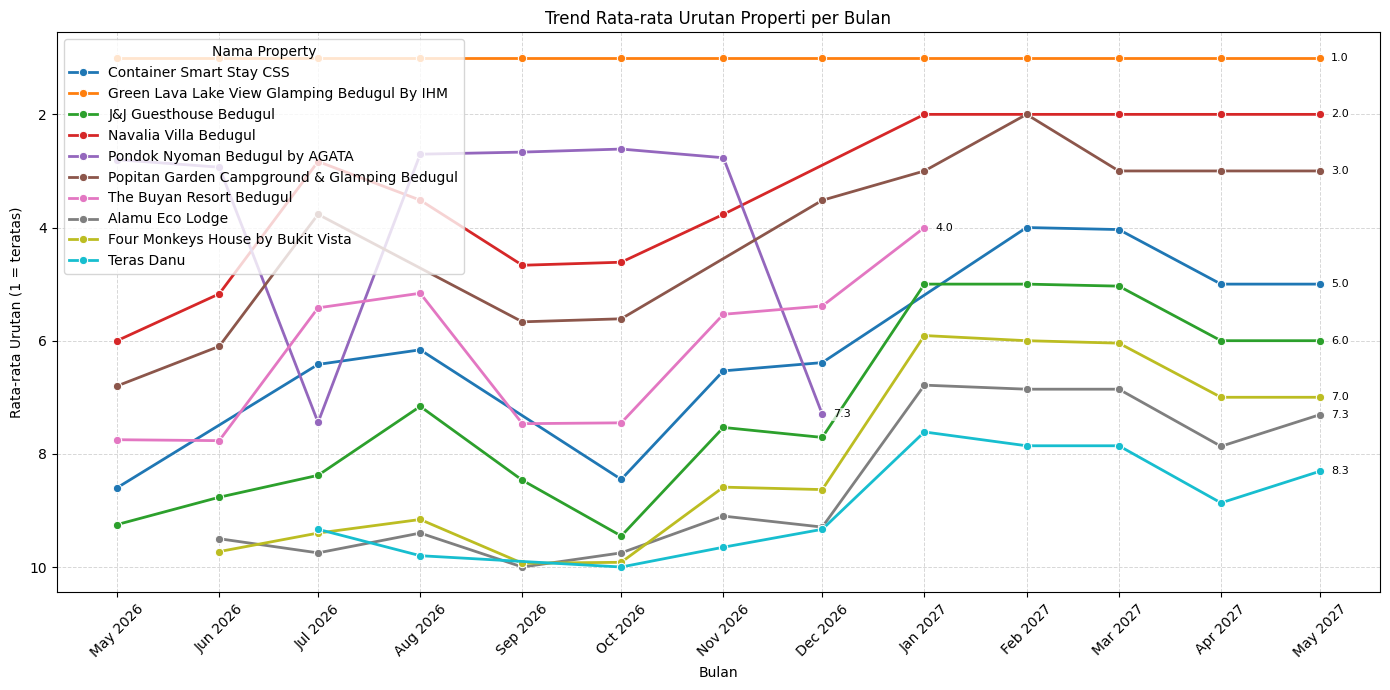

In [ ]:
# Pastikan kolom tanggal berbentuk datetime
df['Check-in'] = pd.to_datetime(df['Check-in'])

# Buat ranking berdasarkan urutan di setiap tanggal
df['order_rank'] = df.groupby('Check-in').cumcount() + 1

# Ambil 10 properti terbanyak
top_order_props = df['Nama Property'].value_counts().nlargest(10).index

# Filter hanya properti top 10
order_trend = df[df['Nama Property'].isin(top_order_props)].copy()

# Buat kolom bulan
order_trend['Bulan'] = order_trend['Check-in'].dt.to_period('M').dt.to_timestamp()

# Hitung rata-rata ranking per bulan
monthly_avg = (
    order_trend
    .groupby(['Bulan', 'Nama Property'])['order_rank']
    .mean()
    .reset_index()
)

# =========================
# Plot
# =========================
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=monthly_avg,
    x='Bulan',
    y='order_rank',
    hue='Nama Property',
    marker='o',
    linewidth=2
)

# Balik sumbu Y
plt.gca().invert_yaxis()

# Format bulan
months_sorted = sorted(monthly_avg['Bulan'].unique())

plt.xticks(
    months_sorted,
    [d.strftime('%b %Y') for d in months_sorted],
    rotation=45
)

# Tambahkan grid vertikal & horizontal per bulan
ax.grid(
    True,
    which='major',
    axis='both',
    linestyle='--',
    linewidth=0.7,
    alpha=0.5
)

# Tambahkan label di titik terakhir tiap garis
# for line in ax.lines:

#     x_data = line.get_xdata()
#     y_data = line.get_ydata()

#     if len(x_data) == 0:
#         continue

#     x_last = x_data[-1]
#     y_last = y_data[-1]

#     ax.annotate(
#         f'{y_last:.1f}',
#         xy=(x_last, y_last),
#         xytext=(8, 0),
#         textcoords='offset points',
#         fontsize=8,
#         va='center',
#         bbox=dict(
#             facecolor='white',
#             alpha=0.7,
#             edgecolor='none',
#             pad=1
#         )
#     )

plt.title('Trend Rata-rata Urutan Properti per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Urutan (1 = teratas)')

plt.tight_layout()
plt.show()

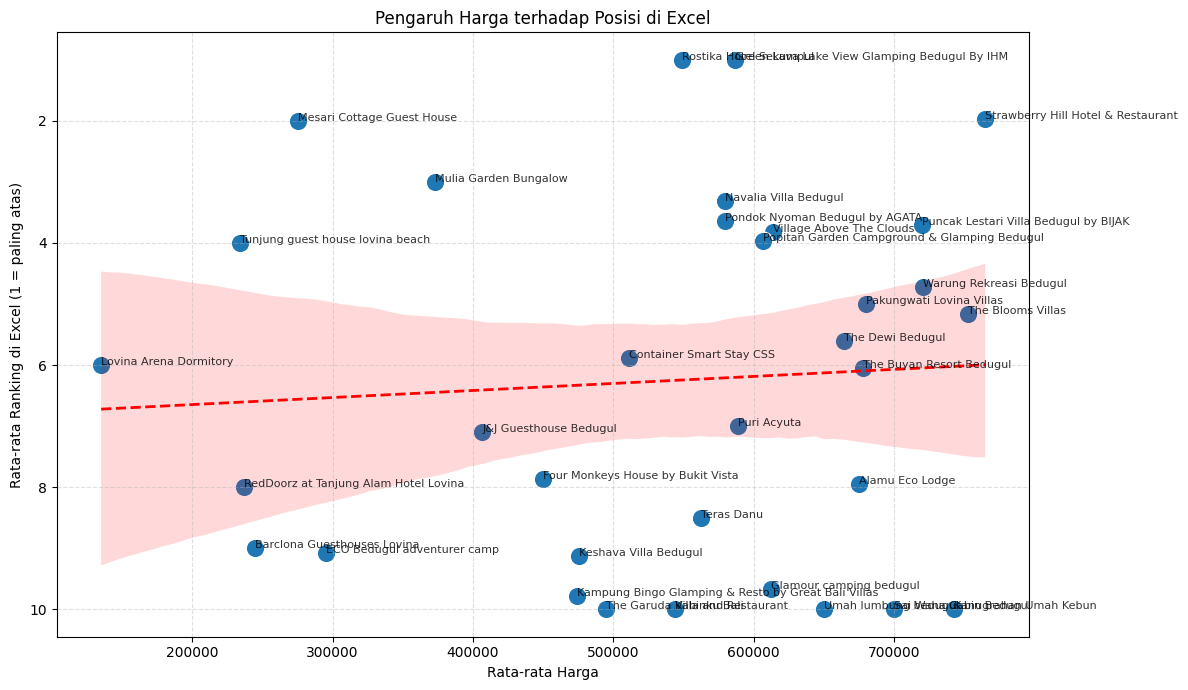

Korelasi Harga vs Ranking Excel: -0.068


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pastikan datetime
df['Check-in'] = pd.to_datetime(df['Check-in'])

# Ranking urutan berdasarkan posisi di Excel
df['Ranking_Excel'] = df.groupby('Check-in').cumcount() + 1

# =========================
# Agregasi per Property
# =========================
analysis = (
    df.groupby('Nama Property')
    .agg({
        'Harga': 'mean',
        'Ranking_Excel': 'mean'
    })
    .reset_index()
)

# Urutkan biar rapi
analysis = analysis.sort_values('Harga', ascending=False)

# =========================
# Scatter Plot
# =========================
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=analysis,
    x='Harga',
    y='Ranking_Excel',
    s=180
)

# Garis trend
sns.regplot(
    data=analysis,
    x='Harga',
    y='Ranking_Excel',
    scatter=False,
    color='red',
    line_kws={'linestyle': '--', 'linewidth': 2}
)

# Label nama property
for _, row in analysis.iterrows():

    plt.text(
        row['Harga'],
        row['Ranking_Excel'],
        row['Nama Property'],
        fontsize=8,
        alpha=0.8
    )

# Karena ranking kecil = lebih atas
plt.gca().invert_yaxis()

plt.title('Pengaruh Harga terhadap Posisi di Excel')
plt.xlabel('Rata-rata Harga')
plt.ylabel('Rata-rata Ranking di Excel (1 = paling atas)')

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Korelasi
correlation = analysis['Harga'].corr(analysis['Ranking_Excel'])

print(f'Korelasi Harga vs Ranking Excel: {correlation:.3f}')